# 📊 Evaluating LLMs (and Potential Pitfalls)

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/02-llms/10-evaluating-llms/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/02-llms/10-evaluating-llms/index.qmd)

By now you have trained a model ([\[02.2\] Parallel
Training](../06-parallel-training/index.qmd)), taught it to follow
instructions, and even nudged it toward *reasoning* with reinforcement
learning ([\[03.4\] RL &
Reasoning](../../03-advanced-llms/4-rl-and-reasoning/index.qmd)). This
capstone ties all of that together with one deceptively simple question:

> **How do you actually know your model got better?**

It sounds simple. It is not. This page is more conceptual than the labs
— we spend most of it on *how to think* about evaluation — but we keep
it hands-on with a tiny, runnable eval harness you can extend for your
homework.

> **Still-useful resources from the ALCF series**
>
> - 📄 [Overview of LLM
>   Evaluation](https://github.com/argonne-lcf/ai-science-training-series/blob/main/08_Evaluating_LLMs/LLM_Evaluation_Overview.pdf)
>   (also mirrored locally as `LLM_Evaluation_Overview.pdf`)
> - 📄 [Potential Pitfalls of
>   LLMs](https://github.com/argonne-lcf/ai-science-training-series/blob/main/08_Evaluating_LLMs/LLM-Pitfalls.pdf)
>   (also `LLM-Pitfalls.pdf`)
> - 🧮 [OpenAI Tokenizer](https://platform.openai.com/tokenizer) — feel
>   your prompts get chopped into tokens
> - 🥊 [Chatbot Arena](https://lmarena.ai/) — blind, head-to-head human
>   voting
> - 🛡️ [Chatbot Guardrails
>   Arena](https://huggingface.co/spaces/lighthouzai/guardrails-arena) —
>   adversarial safety testing

## 🤔 Why Evaluation Is Hard

Classifiers are easy to score: the label is right or wrong, and accuracy
is a single number everyone agrees on. Generative models break all three
of those comforts.

- **Generation is open-ended.** For the prompt *“Explain entropy to a
  first-year student,”* there is no single correct string. Thousands of
  good answers exist and infinitely many bad ones. String-matching a
  reference answer punishes correct-but-differently-worded responses.
- **Benchmarks saturate.** A benchmark is useful only while models still
  fail it. [MMLU](https://arxiv.org/abs/2009.03300) was hard in 2020;
  today frontier models score in the 88–90% range, so a 1-point gain is
  mostly noise. Once headroom vanishes, the benchmark stops
  discriminating between models.
- **Contamination.** Models train on scraped web text, and benchmarks
  *live* on the web. If GSM8K problems (or their answers) leaked into
  pretraining, a high score measures *memorization*, not reasoning. This
  is the single most corrosive problem in the field and we return to it
  in [Pitfalls](#sec-pitfalls).

> **The core tension**
>
> We want a **cheap, automatic, reproducible** number that tracks a
> **rich, subjective, human** notion of quality. Every evaluation method
> is a different compromise between those two poles.

## 🗂️ Categories of Evaluation

There is no single “LLM score.” Instead there is a toolbox, and each
tool trades off cost, objectivity, and how well it correlates with what
you actually care about.

<figure id="fig-eval-taxonomy">
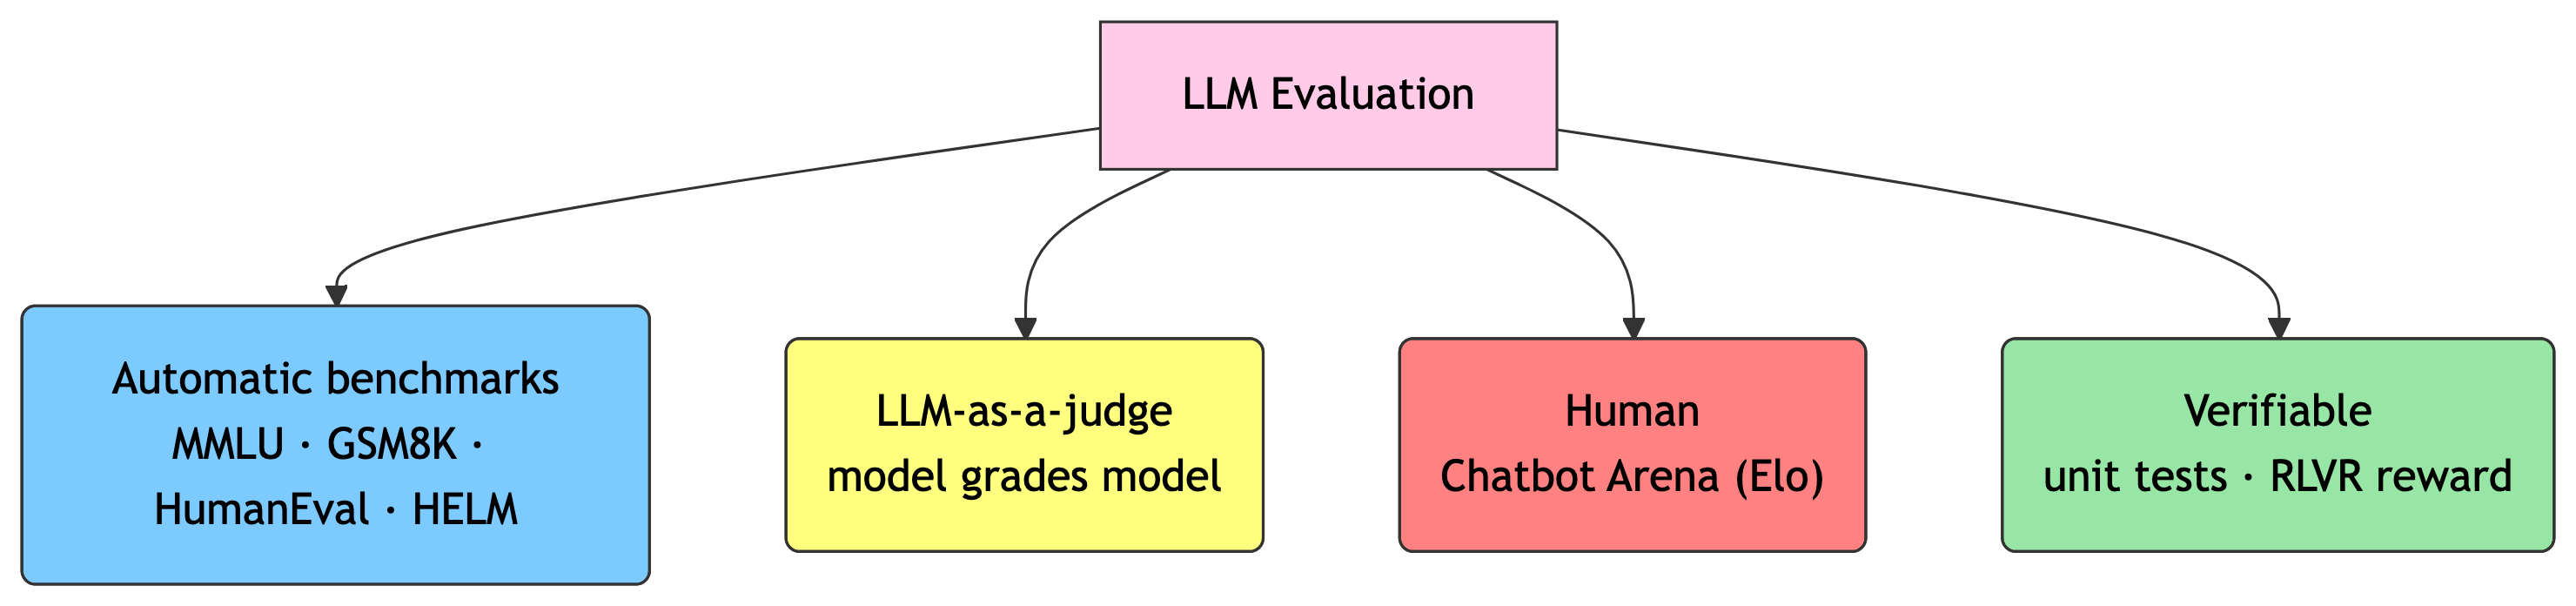
<figcaption>Figure 1: Four families of LLM evaluation, from
cheap-and-automatic (benchmarks) to expensive-and-human
(arena).</figcaption>
</figure>

### (a) Automatic benchmarks

Fixed datasets of questions with known answers, scored by a script.
Fast, reproducible, and comparable across papers — which is exactly why
they get gamed and saturated.

| Benchmark | Measures | Scoring |
|:-----------------------|:-----------------------|:-----------------------|
| [MMLU](https://arxiv.org/abs/2009.03300) | Knowledge across 57 subjects | Multiple-choice accuracy |
| [GSM8K](https://arxiv.org/abs/2110.14168) | Grade-school math word problems | Exact-match on final number |
| [MATH](https://arxiv.org/abs/2103.03874) | Competition mathematics | Answer equivalence |
| [HumanEval](https://arxiv.org/abs/2107.03374) | Python code generation | `pass@k` (run the tests!) |
| [BIG-bench](https://arxiv.org/abs/2206.04615) | 200+ diverse, “hard” tasks | Task-specific |
| [HELM](https://arxiv.org/abs/2211.09110) | *Holistic* — many metrics × many scenarios | Multi-metric report card |

A sampling of widely-used LLM benchmarks {.table-responsive
.table-striped .table-hover}

HELM deserves a special mention: instead of one number, it reports
accuracy *alongside* calibration, robustness, fairness, bias, toxicity,
and efficiency — a deliberate pushback against single-number thinking.

### (b) LLM-as-a-judge

Use a strong model (e.g. GPT-4-class) to *grade* another model’s
open-ended output against a rubric or a reference. This scales
human-like judgment to thousands of examples for pennies, and correlates
surprisingly well with human preferences — but it inherits the judge’s
biases (see [Pitfalls](#sec-pitfalls)).

### (c) Human evaluation & Chatbot Arena

The gold standard is still a human deciding which of two responses is
better. [Chatbot Arena](https://arxiv.org/abs/2403.04132) crowdsources
this at scale: users chat with two anonymous models, vote for the
winner, and the votes feed a **Bradley–Terry / Elo** rating. Each
pairwise outcome nudges the ratings:

$$\hat{p}(A \text{ beats } B) = \frac{1}{1 + 10^{(R_B - R_A)/400}},
\qquad
R_A \leftarrow R_A + K\big(S_A - \hat{p}\big)$$

where $R$ are ratings, $S_A \in \{0, 1\}$ is the observed outcome, and
$K$ is the update step. Elo turns a pile of noisy A-vs-B votes into a
single ranked leaderboard.

### (d) Verifiable / programmatic evaluation

Some tasks have a *checkable* ground truth: code either passes its unit
tests or it doesn’t; a math answer is either correct or not; JSON either
parses or it doesn’t. This is the cleanest possible signal — no judge,
no subjectivity.

> **🔗 This is exactly RLVR**
>
> Verifiable evaluation is the same idea as **RL with Verifiable Rewards
> (RLVR)** from [\[03.4\] RL &
> Reasoning](../../03-advanced-llms/4-rl-and-reasoning/index.qmd).
> There, a programmatic verifier (test suite, math checker) *is* the
> reward signal used to train the model. Here, that same verifier *is*
> the evaluation metric. Train-time reward and eval-time metric are two
> faces of the same function — which, foreshadowing, is precisely why
> [reward hacking](#sec-pitfalls) is so dangerous.

## 📏 Metrics That Matter

### Perplexity

Recall from [\[02.0\] Intro to LLMs](../00-intro-to-llms/index.qmd) that
**perplexity** is the exponentiated cross-entropy loss,
$\text{PPL} = \exp(\text{CE})$ — “how surprised is the model by held-out
text?” Lower is better. It is great for tracking *pretraining* progress
on a fixed corpus, but says little about downstream usefulness, and it
is **not comparable across different tokenizers** (more in
[Pitfalls](#sec-pitfalls)).

### Accuracy and `pass@k`

For tasks with a right answer, **accuracy** is the fraction correct. For
code and other sample-many-times settings,
[HumanEval](https://arxiv.org/abs/2107.03374) popularized **`pass@k`**:
the probability that *at least one* of $k$ sampled solutions passes.
Given $n \ge k$ total samples of which $c$ are correct, the unbiased
estimator is

$$\text{pass@}k = \mathbb{E}\left[\,1 - \frac{\binom{n-c}{k}}{\binom{n}{k}}\,\right].$$

### Win-rate

For open-ended tasks scored by pairwise comparison (human or LLM-judge),
the natural metric is the **win-rate**: the fraction of head-to-head
matchups your model wins. Elo (above) is just a smarter way of
aggregating win-rates that accounts for *who* you beat.

## 👋 Hands On: A Tiny Eval Harness

Let’s make this concrete. The cell below is a complete, self-contained
eval harness in plain `numpy` — no GPU, no heavy libraries. It computes
**exact match**, a **format check**, and the unbiased **`pass@k`**
estimator over a handful of `(prediction, reference)` pairs. You can
flip these ideas onto a real model in the homework.

In [2]:
import numpy as np

# --- a tiny "dataset": (model prediction, gold reference) -------------------
pairs = [
    ("The answer is 42.",      "42"),
    ("42",                     "42"),
    ("forty-two",              "42"),   # correct idea, wrong format
    ("The answer is 41.",      "42"),   # just wrong
    ("  42  ",                 "42"),   # right, but whitespace
]

def normalize(s: str) -> str:
    """Lowercase, strip, collapse whitespace -- a minimal answer normalizer."""
    return " ".join(s.lower().split())

def extract_number(s: str) -> str:
    """Pull the last integer out of a string (a common GSM8K-style parse)."""
    toks = [t for t in "".join(c if c.isdigit() else " " for c in s).split()]
    return toks[-1] if toks else ""

# --- metric 1: strict exact match (after normalization) ---------------------
exact = np.mean([normalize(p) == normalize(r) for p, r in pairs])

# --- metric 2: lenient "extract-then-match" (format-robust) -----------------
lenient = np.mean([extract_number(p) == extract_number(r) for p, r in pairs])

print(f"strict exact-match accuracy : {exact:.2f}")
print(f"lenient extract accuracy    : {lenient:.2f}")

strict exact-match accuracy : 0.40
lenient extract accuracy    : 0.60

The two metrics disagree (strict `0.40` vs. lenient `0.60`).
`"forty-two"` fails both — it has no digits to extract. `"  42  "`
passes both, since normalization strips the whitespace. But
`"The answer is 42."` is *wrong* under strict matching (it isn’t
literally `"42"`) yet *right* under lenient extraction (the last number
is `42`). **The metric you choose changes the score** — a theme we
hammer on below.

Now the `pass@k` estimator, implemented in the numerically stable
product form from the HumanEval paper (it never builds huge binomial
coefficients):

In [3]:
def pass_at_k(n: int, c: int, k: int) -> float:
    """Unbiased pass@k: n total samples, c correct, top-k budget."""
    if n - c < k:          # more correct than the "all-wrong" slots -> guaranteed
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

# Suppose we sampled n=10 completions per problem for 3 problems,
# and counted how many passed the unit tests:
samples = [("problem_A", 10, 4), ("problem_B", 10, 1), ("problem_C", 10, 0)]

for name, n, c in samples:
    p1  = pass_at_k(n, c, 1)
    p5  = pass_at_k(n, c, 5)
    print(f"{name}: c={c}/{n}  pass@1={p1:.2f}  pass@5={p5:.2f}")

# Aggregate pass@k = mean over problems
for k in (1, 5):
    agg = np.mean([pass_at_k(n, c, k) for _, n, c in samples])
    print(f"aggregate pass@{k} = {agg:.3f}")

problem_A: c=4/10  pass@1=0.40  pass@5=0.98
problem_B: c=1/10  pass@1=0.10  pass@5=0.50
problem_C: c=0/10  pass@1=0.00  pass@5=0.00
aggregate pass@1 = 0.167
aggregate pass@5 = 0.492

`pass@5` is always $\ge$ `pass@1`: with more attempts you are more
likely to land at least one passing solution. `problem_C` never passes,
so its `pass@k` is 0 for any $k$. This single idea — *sample many, check
programmatically, report the best* — is the backbone of code and math
evaluation.

### A real harness (display-only)

In practice you would not hand-roll this. The community standard is
EleutherAI’s
[`lm-evaluation-harness`](https://github.com/EleutherAI/lm-evaluation-harness)
(the same tool behind the Hugging Face Open LLM Leaderboard). A typical
run looks like this — shown for reference, **not executed here**:

``` bash
# install once
uv pip install lm-eval

# evaluate a small model on MMLU + GSM8K, 5-shot, batched
lm_eval --model hf \
    --model_args pretrained=EleutherAI/pythia-160m \
    --tasks mmlu,gsm8k \
    --num_fewshot 5 \
    --batch_size auto \
    --output_path results/pythia-160m.json
```

On an ALCF system you would wrap that launch with `ezpz` to fan it out
across ranks, exactly as you did for training:

``` bash
ezpz launch lm_eval --model hf \
    --model_args pretrained=<your-model> \
    --tasks gsm8k \
    --output_path results/eval.json
```

## ⚠️ Potential Pitfalls

This is the *“and potential pitfalls”* half of the title — arguably the
most important part of the page. Every number you report is an attack
surface. Here are the ways evaluation lies.

> **Benchmark contamination**
>
> If the test set (or its answers) appeared in pretraining data, a high
> score measures memorization, not capability. Contamination is often
> invisible: web crawls are enormous and benchmarks get copied
> everywhere. **Mitigations:** prefer *held-out* or freshly-collected
> tasks, check for verbatim overlap, watch for suspiciously large jumps
> on old benchmarks, and treat any single benchmark number with
> suspicion.

> **Prompt sensitivity**
>
> The *same* model on the *same* benchmark can swing several points
> depending on phrasing, few-shot examples, answer-extraction regex, and
> whether you use a chat template. A reported delta between two models
> can vanish (or reverse) under a different prompt. **Always report the
> exact prompt, few-shot count, and parsing rules**, and compare models
> under *identical* harness settings.

> **Tokenizer / format mismatch**
>
> Perplexity is **not comparable across tokenizers** — a model that
> splits text into more tokens will report a different per-token loss
> for the same string. Likewise, answer-extraction that assumes one
> output format (“The answer is X”) silently zeroes out a model that
> formats differently but answers correctly (see `"forty-two"` above).
> Normalize carefully, and never compare raw perplexities across model
> families.

> **Gaming metrics / reward hacking**
>
> This is the deep connection to [\[03.4\] RL &
> Reasoning](../../03-advanced-llms/4-rl-and-reasoning/index.qmd). When
> a metric becomes a *training target* (RLVR reward, or “optimize for
> the benchmark”), the model learns to maximize the *measure* rather
> than the *thing you meant*. A code model may pass tests by hard-coding
> expected outputs; a chat model rewarded for length may become
> needlessly verbose.
>
> > *“When a measure becomes a target, it ceases to be a good measure.”*
> > — Goodhart’s Law
>
> Keep an eval set that the model is **never** trained or tuned against.

> **Position & style bias in LLM-judges**
>
> LLM-as-a-judge is convenient but biased. Judges tend to favor the
> *first* (or *second*) response shown regardless of quality (**position
> bias**), prefer *longer* and more *confident* answers
> (**verbosity/style bias**), and rate their own outputs higher
> (**self-preference**). **Mitigations:** randomize order, average over
> both orderings, control for length, and calibrate against human votes
> before trusting the judge.

> **Over-reliance on a single benchmark**
>
> No single number captures “is this model good.” A model can top MMLU
> and be a poor coder, or ace GSM8K and hallucinate constantly. This is
> the entire motivation behind
> [HELM](https://arxiv.org/abs/2211.09110)’s multi-metric report card.
> **Report a portfolio** — capability, robustness, calibration, safety,
> cost — and weight it toward *your* actual use case.

## 🎒 Homework

Pick a small model you can run on a login node or laptop (e.g. `gpt2`,
`EleutherAI/pythia-160m`, or the mini-LLM you built in [\[02.0\] Intro
to LLMs](../00-intro-to-llms/index.qmd)) and a small task (a slice of
GSM8K, a set of factual Q&A, or a format-following task).

1.  **Evaluate the model with two *different* metrics** on the same task
    — for example **strict exact-match vs. lenient extract-then-match**,
    or **`pass@1` vs. `pass@5`**. You may adapt the `numpy` harness
    above, or use `lm-evaluation-harness`.
2.  **Find at least three examples where the two metrics disagree** and,
    for each, explain *why*: is it a formatting artifact, a parsing bug,
    a genuinely ambiguous answer, or contamination?
3.  **Write a short paragraph** arguing which metric you would trust for
    *your* task, and describe one pitfall from the section above that
    could still fool your chosen metric.

Submit *proof* that you ran the evaluation. *Proof* can be any of:

- The printed output from your harness (the accuracy / `pass@k` numbers)
- A path to a results file (e.g. the `lm_eval --output_path` JSON) on
  the ALCF filesystems
- A screenshot of the run, or a table of your disagreeing examples
- A link to a file in your GitHub repo with your answers

The point is not to get a high score — it is to *distrust* the score you
get, and to be able to say exactly *why* two reasonable metrics
disagree.

## 📚 References

- Hendrycks et al., *Measuring Massive Multitask Language Understanding*
  (MMLU), [arXiv:2009.03300](https://arxiv.org/abs/2009.03300)
- Chen et al., *Evaluating Large Language Models Trained on Code*
  (HumanEval / `pass@k`),
  [arXiv:2107.03374](https://arxiv.org/abs/2107.03374)
- Cobbe et al., *Training Verifiers to Solve Math Word Problems*
  (GSM8K), [arXiv:2110.14168](https://arxiv.org/abs/2110.14168)
- Hendrycks et al., *Measuring Mathematical Problem Solving* (MATH),
  [arXiv:2103.03874](https://arxiv.org/abs/2103.03874)
- Srivastava et al., *Beyond the Imitation Game* (BIG-bench),
  [arXiv:2206.04615](https://arxiv.org/abs/2206.04615)
- Liang et al., *Holistic Evaluation of Language Models* (HELM),
  [arXiv:2211.09110](https://arxiv.org/abs/2211.09110)
- Chiang et al., *Chatbot Arena: An Open Platform for Evaluating LLMs by
  Human Preference*,
  [arXiv:2403.04132](https://arxiv.org/abs/2403.04132)
- EleutherAI,
  [`lm-evaluation-harness`](https://github.com/EleutherAI/lm-evaluation-harness)

Last updated: 2026-07-22 10:15